In [1]:
from google.colab import files
uploaded = files.upload()

Saving normal-final.xlsx to normal-final.xlsx


In [ ]:
import pandas as pd
df = pd.read_excel('normal-final.xlsx')
df.head()

,488.0,0.0,23.9,43.6
0,491,0,24,43.5
1,481,0,24,43.5
2,477,0,24,43.4
3,467,0,24,43.4
4,465,0,24,43.2


In [ ]:
import pandas as pd

df.columns = ["gas", "flame","temp", "humidity"]

In [ ]:
df.head()

,gas,flame,temp,humidity
0,491,0,24,43.5
1,481,0,24,43.5
2,477,0,24,43.4
3,467,0,24,43.4
4,465,0,24,43.2


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving gas-leaking-final.xlsx to gas-leaking-final.xlsx


In [ ]:
import pandas as pd
df = pd.read_excel('gas-leaking-final.xlsx')
df.head()

,838.0,0.0,23.7,41.6
0,844,0,23.7,41.7
1,1868,0,23.7,41.7
2,2445,0,23.7,41.7
3,2653,0,23.7,41.7
4,2708,0,23.7,41.7


In [ ]:
import pandas as pd

df.columns = ["gas", "flame","temp", "humidity"]

In [ ]:
df.head()

,gas,flame,temp,humidity
0,844,0,23.7,41.7
1,1868,0,23.7,41.7
2,2445,0,23.7,41.7
3,2653,0,23.7,41.7
4,2708,0,23.7,41.7


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cooking_pro.csv to cooking_pro.csv
Saving fire_data.csv to fire_data.csv
Saving gas-leaking-final.xlsx to gas-leaking-final (1).xlsx
Saving normal-final.xlsx to normal-final (1).xlsx


In [ ]:
import pandas as pd

# Read normal data, setting column names explicitly
normal = pd.read_excel("normal-final.xlsx", header=None)
normal.columns = ["gas", "flame", "temp", "humidity"]

# Read cooking data
cooking = pd.read_csv("cooking_pro.csv")

# Read gas leak data, setting column names explicitly
gas_leak = pd.read_excel("gas-leaking-final.xlsx", header=None)
gas_leak.columns = ["gas", "flame", "temp", "humidity"]

# Read fire data and rename 'flam' to 'flame'
fire = pd.read_csv("fire_data.csv")
fire = fire.rename(columns={'flam': 'flame'})

# Add 'status' column to each DataFrame
normal["status"] = "Normal"
cooking["status"] = "Cooking"
gas_leak["status"] = "Gas Leak"
fire["status"] = "Fire"

# Concatenate all DataFrames
df = pd.concat([normal, cooking, gas_leak, fire], axis=0)

df = df.reset_index(drop=True)
cols = ["status"] + [col for col in df.columns if col != "status"]
df = df[cols]

print(df.head())

   status  gas flame  temp humidity
0  Normal  488     0  23.9     43.6
1  Normal  491     0    24     43.5
2  Normal  481     0    24     43.5
3  Normal  477     0    24     43.4
4  Normal  467     0    24     43.4


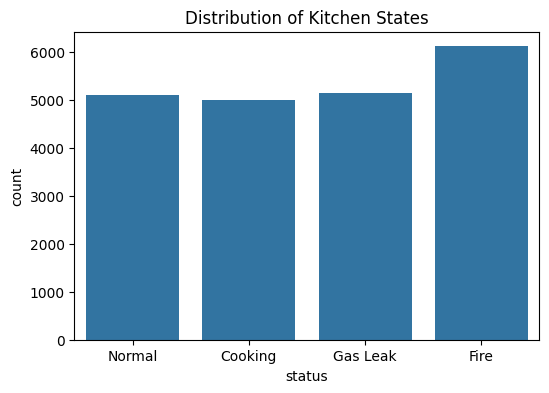

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="status")
plt.title("Distribution of Kitchen States")
plt.show()

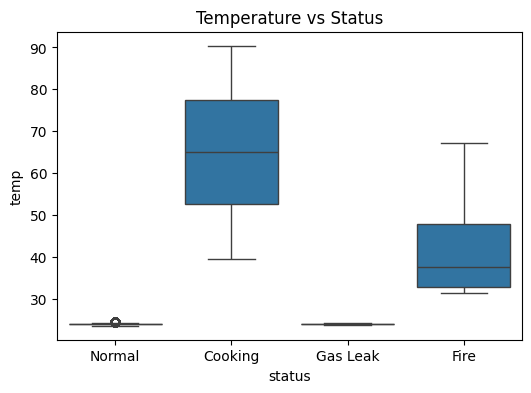

In [ ]:
plt.figure(figsize=(6,4))
df['temp'] = pd.to_numeric(df['temp'], errors='coerce')
sns.boxplot(x="status", y="temp", data=df)
plt.title("Temperature vs Status")
plt.show()

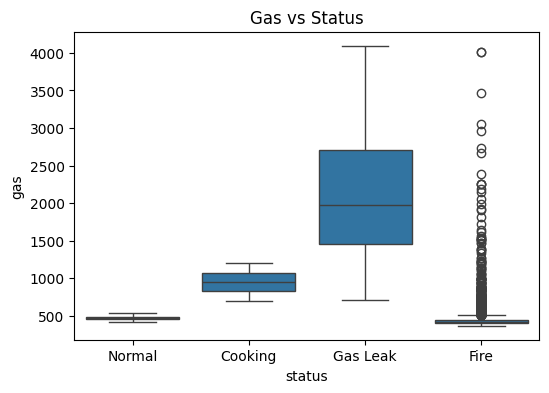

In [ ]:
plt.figure(figsize=(6,4))
df['gas'] = pd.to_numeric(df['gas'], errors='coerce')
sns.boxplot(x="status", y="gas", data=df)
plt.title("Gas vs Status")
plt.show()

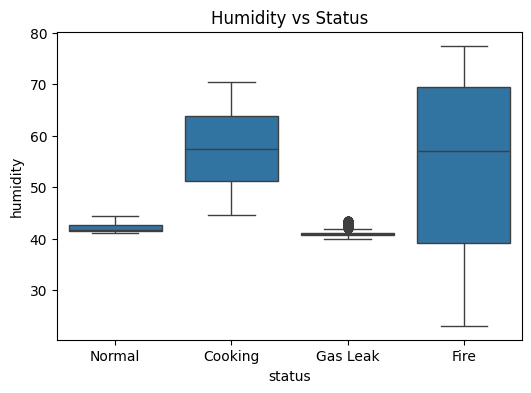

In [ ]:
plt.figure(figsize=(6,4))
df['humidity'] = pd.to_numeric(df['humidity'], errors='coerce')
sns.boxplot(x="status", y="humidity", data=df)
plt.title("Humidity vs Status")
plt.show()

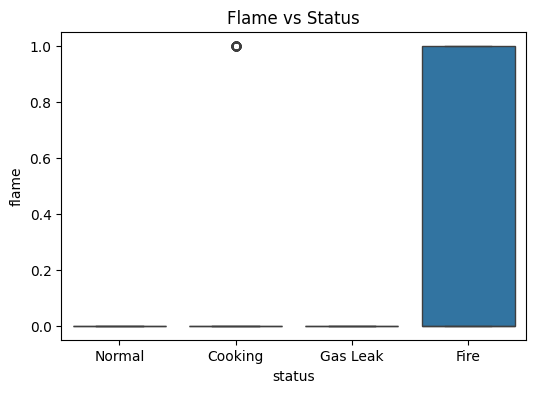

In [ ]:
plt.figure(figsize=(6,4))
df['flame'] = pd.to_numeric(df['flame'], errors='coerce')
sns.boxplot(x="status", y="flame", data=df)
plt.title("Flame vs Status")
plt.show()

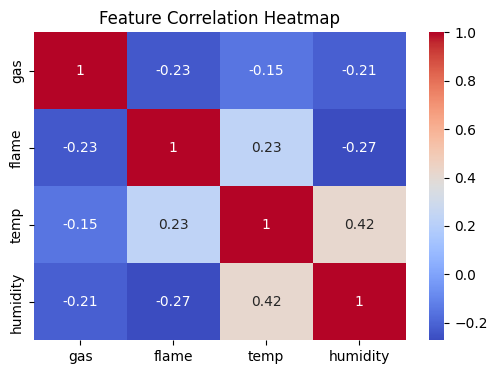

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
print(f"\n number of rows: {df.shape[0]}")


 number of rows: 21376


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21376 entries, 0 to 21375
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   status    21376 non-null  object 
 1   gas       21369 non-null  float64
 2   flame     21369 non-null  float64
 3   temp      21369 non-null  float64
 4   humidity  21369 non-null  float64
dtypes: float64(4), object(1)
memory usage: 835.1+ KB
None


In [ ]:
print(df.isnull().sum())

status      0
gas         7
flame       7
temp        7
humidity    7
dtype: int64


In [ ]:
print(df.dtypes)

status       object
gas         float64
flame       float64
temp        float64
humidity    float64
dtype: object


In [ ]:
print(df.describe())

                gas         flame          temp      humidity
count  21369.000000  21369.000000  21369.000000  21369.000000
mean     968.756224      0.136553     38.437858     48.705275
std      791.883014      0.343383     18.513647     11.584443
min      367.870000      0.000000     23.500000     23.130000
25%      444.370000      0.000000     23.900000     41.100000
50%      518.350000      0.000000     31.820000     42.700000
75%     1115.230000      0.000000     49.660000     58.150000
max     4095.000000      1.000000     90.400000     77.460000


In [ ]:
df = df.dropna()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["status"] = le.fit_transform(df["status"])

/tmp/ipykernel_23969/520725581.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["status"] = le.fit_transform(df["status"])


In [ ]:
df = df.sample(frac=1).reset_index(drop=True)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features = ["gas", "flame", "temp", "humidity"]

df[features] = scaler.fit_transform(df[features])

In [ ]:
df = df.sample(frac=1).reset_index(drop=True)

In [ ]:
df.to_csv("smart_kitchen_dataset.csv", index=False)

In [ ]:
df.head(10)

,status,gas,flame,temp,humidity
0,0,-0.250177,-0.397679,0.492197,0.000408
1,1,-0.703815,-0.397679,-0.358547,1.994508
2,0,-0.238534,-0.397679,0.555935,0.028032
3,0,0.122399,2.514591,2.040280,1.278877
4,3,-0.643742,-0.397679,-0.790671,-0.578831
5,3,-0.639953,-0.397679,-0.769065,-0.604728
6,0,-0.043437,-0.397679,1.376970,0.736757
7,3,-0.638690,-0.397679,-0.779868,-0.613361
8,2,0.674666,-0.397679,-0.790671,-0.691053
9,0,-0.313622,-0.397679,0.197812,-0.200729


In [ ]:
print(df.isnull().sum())

status      0
gas         0
flame       0
temp        0
humidity    0
dtype: int64


In [ ]:
from google.colab import files

files.download("smart_kitchen_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving smart_kitchen_dataset2.csv to smart_kitchen_dataset2.csv


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import joblib

In [5]:
df = pd.read_csv("smart_kitchen_dataset2.csv")

df.head()

,status,gas,flame,temp,humidity
0,0,-0.250177,-0.397679,0.492197,0.000408
1,1,-0.703815,-0.397679,-0.358547,1.994508
2,0,-0.238534,-0.397679,0.555935,0.028032
3,0,0.122399,2.514591,2.040280,1.278877
4,3,-0.643742,-0.397679,-0.790671,-0.578831


In [6]:
print(df["status"].value_counts())

status
1    6121
2    5138
3    5110
0    5000
Name: count, dtype: int64


In [7]:
X = df[["gas", "flame", "temp", "humidity"]]
y = df["status"]

In [8]:
from sklearn.utils import resample

df_safe = df[df["status"] == 0]
df_other = df[df["status"] != 0]

df_other_up = resample(
    df_other,
    replace=True,
    n_samples=len(df_safe),
    random_state=42
)

df_balanced = pd.concat([df_safe, df_other_up])

X = df_balanced[["gas", "flame", "temp", "humidity"]]
y = df_balanced["status"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       random_state=42)

In [13]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      1.00      1.00       378
           2       1.00      1.00      1.00       304
           3       1.00      1.00      1.00       318

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [14]:
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [15]:
sample = pd.DataFrame([[200, 1, 85, 30]],
                      columns=["gas", "flame", "temp", "humidity"])

sample_scaled = scaler.transform(sample)

pred = model.predict(sample_scaled)[0]

print("Prediction:", pred)

Prediction: 0


In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      1.00      1.00       378
           2       1.00      1.00      1.00       304
           3       1.00      1.00      1.00       318

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



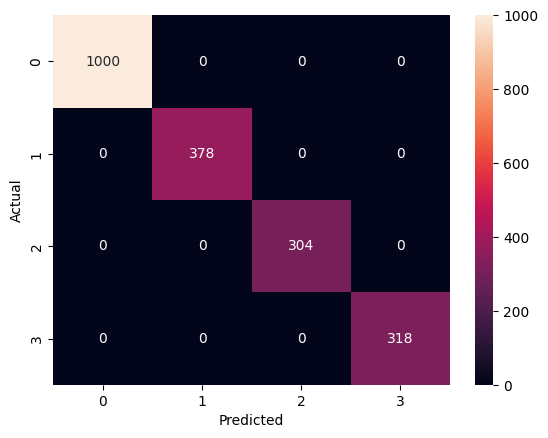

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
import joblib
import numpy as np

model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")

In [19]:
def risk_layer(prediction):
    if prediction == 0:
        return "SAFE"

    elif prediction == 1:
        return "LOW WARNING (Cooking detected)"

    elif prediction == 2:
        return "HIGH WARNING (Gas Leak Risk)"

    else:
        return "CRITICAL DANGER (Fire Detected)"

In [22]:
def early_warning(gas, flame, temp, humidity):

    alerts = []

    if flame == 1 and temp > 32:
        alerts.append(" Fire starting detected")

    if temp > 40:
        alerts.append(" High temperature")

    if gas > 700:
        alerts.append(" Gas leak risk")

    return alerts if alerts else ["Safe"]

In [24]:
import pandas as pd

# Example values for sensor data (you can change these)
gas = 200
flame = 1
temp = 85
humidity = 30

sensor = pd.DataFrame([[gas, flame, temp, humidity]],
                      columns=["gas", "flame", "temp", "humidity"])

In [26]:
sensor_scaled = scaler.transform(sensor)

In [27]:
prediction = model.predict(sensor_scaled)[0]

In [28]:
print("ML Prediction:", risk_layer(prediction))

ML Prediction: SAFE


In [29]:
warning = early_warning(gas, flame, temp, humidity)

if warning:
    print(warning)

[' Fire starting detected', ' High temperature']


In [30]:
def run_system(gas, flame, temp, humidity):

    warning = early_warning(gas, flame, temp, humidity)

    print("\n--- SYSTEM OUTPUT ---")

    if warning:
        print("EARLY WARNING:", warning)
    else:
        print("EARLY WARNING: SAFE")

In [31]:
run_system(200, 0, 30, 50)
run_system(350, 0, 60, 55)
run_system(900, 0, 40, 60)
run_system(200, 1, 85, 30)
run_system(700, 1, 70, 50)


--- SYSTEM OUTPUT ---
EARLY WARNING: ['Safe']

--- SYSTEM OUTPUT ---
EARLY WARNING: [' High temperature']

--- SYSTEM OUTPUT ---
EARLY WARNING: [' Gas leak risk']

--- SYSTEM OUTPUT ---
EARLY WARNING: [' Fire starting detected', ' High temperature']

--- SYSTEM OUTPUT ---
EARLY WARNING: [' Fire starting detected', ' High temperature']
